[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All required libraries imported successfully!
Option 1: Traditional ML only (recommended to start)
Option 2: Include BERT training (requires GPU for reasonable speed)

>>> Running ALL MODELS (including BERT) <<<
CYBERBULLYING DETECTION PIPELINE STARTED
LOADING AND EXPLORING DATA
Dataset shape: (16851, 5)

Column names: ['index', 'id', 'Text', 'Annotation', 'oh_label']

First few rows:
                   index                     id  \
0  5.74948705591165E+017  5.74948705591165E+017   
1  5.71917888690393E+017  5.71917888690393E+017   
2  3.90255841338601E+017  3.90255841338601E+017   
3  5.68208850655916E+017  5.68208850655916E+017   
4  5.75596338802373E+017  5.75596338802373E+017   

                                                Text Annotation  oh_label  
0  @halalflaws @biebervalue @greenlinerzjm I read...       none       0.0  
1  @ShreyaBafna3 Now you idiots claim that people...       none       0.0  
2  RT @Mooseoftorment Call me sexist, but when I ...     sexism       1.0  
3

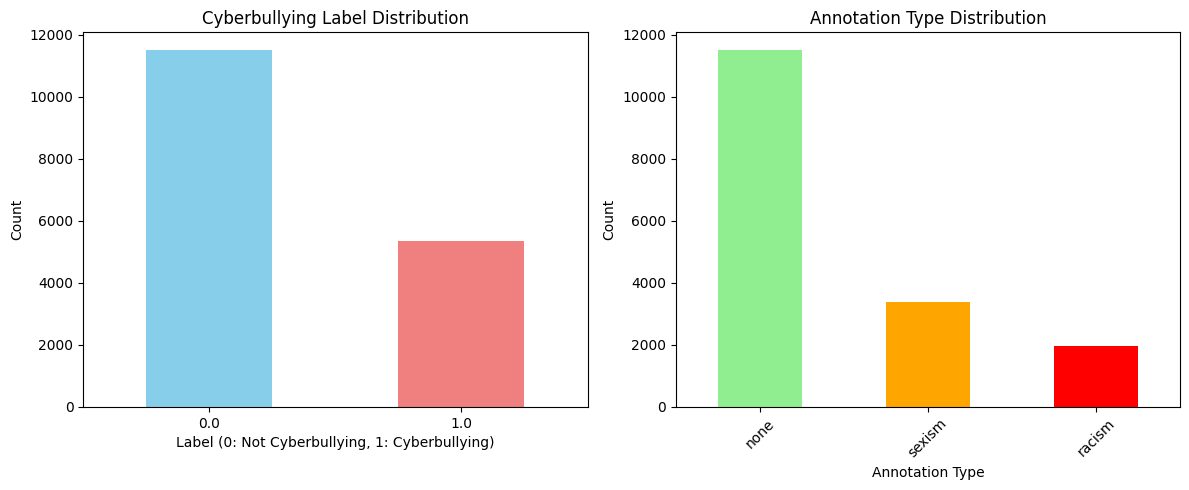

PREPROCESSING DATA
Handling missing values...
Missing values before cleaning:
index         0
id            1
Text          1
Annotation    3
oh_label      3
dtype: int64
Dataset shape after removing missing values: (16848, 5)
Cleaning text data...
Final dataset shape after preprocessing: (16515, 7)
Final target distribution:
oh_label
0    11187
1     5328
Name: count, dtype: int64

Sample cleaned texts:

Original: @halalflaws @biebervalue @greenlinerzjm I read them in context.No change in meaning. The history of Islamic slavery. https://t.co/xWJzpSodGj
Cleaned: read contextno change meaning history islamic slavery

Original: @ShreyaBafna3 Now you idiots claim that people who tried to stop him from becoming a terrorist made him a terrorist. Islamically brain dead.
Cleaned: idiot claim people tried stop becoming terrorist made terrorist islamically brain dead

Original: RT @Mooseoftorment Call me sexist, but when I go to an auto place, I'd rather talk to a guy
Cleaned: call sexist auto 

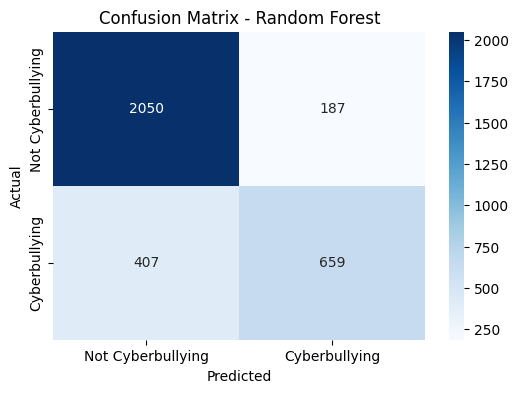


Training SVM...
SVM - Accuracy: 0.8211, F1-Score: 0.6726

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      2237
           1       0.82      0.57      0.67      1066

    accuracy                           0.82      3303
   macro avg       0.82      0.76      0.77      3303
weighted avg       0.82      0.82      0.81      3303



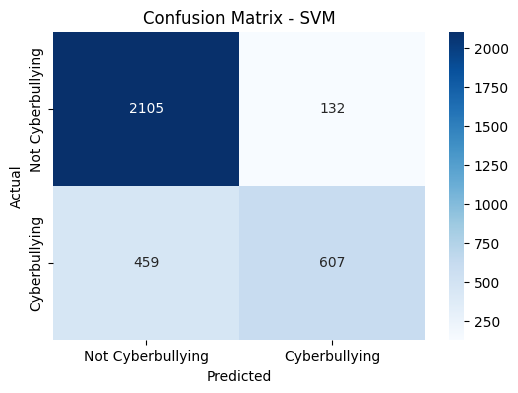


Starting BERT model training...
Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-small and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


GPU: Tesla P100-PCIE-16GB
GPU Memory: 15.9 GB
TRAINING BERT MODEL (Manual Loop)
GPU detected (15.9GB). Using batch sizes: train=16, eval=32
Training batches per epoch: 661
Validation batches: 83
Total training steps: 6610

📚 Epoch 1/10
------------------------------
  Batch 50/661 (7.6%) - Avg Loss: 0.5927
  Batch 100/661 (15.1%) - Avg Loss: 0.5675
  Batch 150/661 (22.7%) - Avg Loss: 0.5413
  Batch 200/661 (30.3%) - Avg Loss: 0.5310
  Batch 250/661 (37.8%) - Avg Loss: 0.5230
  Batch 300/661 (45.4%) - Avg Loss: 0.5108
  Batch 350/661 (53.0%) - Avg Loss: 0.4988
  Batch 400/661 (60.5%) - Avg Loss: 0.4897
  Batch 450/661 (68.1%) - Avg Loss: 0.4829
  Batch 500/661 (75.6%) - Avg Loss: 0.4760
  Batch 550/661 (83.2%) - Avg Loss: 0.4750
  Batch 600/661 (90.8%) - Avg Loss: 0.4693
  Batch 650/661 (98.3%) - Avg Loss: 0.4679
  Batch 661/661 (100.0%) - Avg Loss: 0.4676

🔍 Validating epoch 1...
  ✅ Epoch 1 Complete!
  📊 Train Loss: 0.4676
  📊 Val Loss: 0.3962

📚 Epoch 2/10
---------------------------

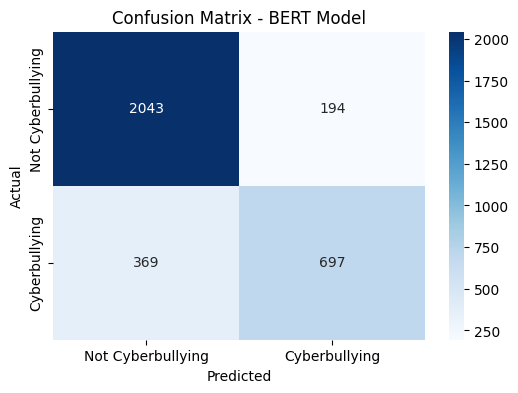

FINAL RESULTS COMPARISON
           Model  Accuracy  F1-Score
0  Random Forest  0.820163  0.689331
1            SVM  0.821072  0.672576
2           BERT  0.829549  0.712315


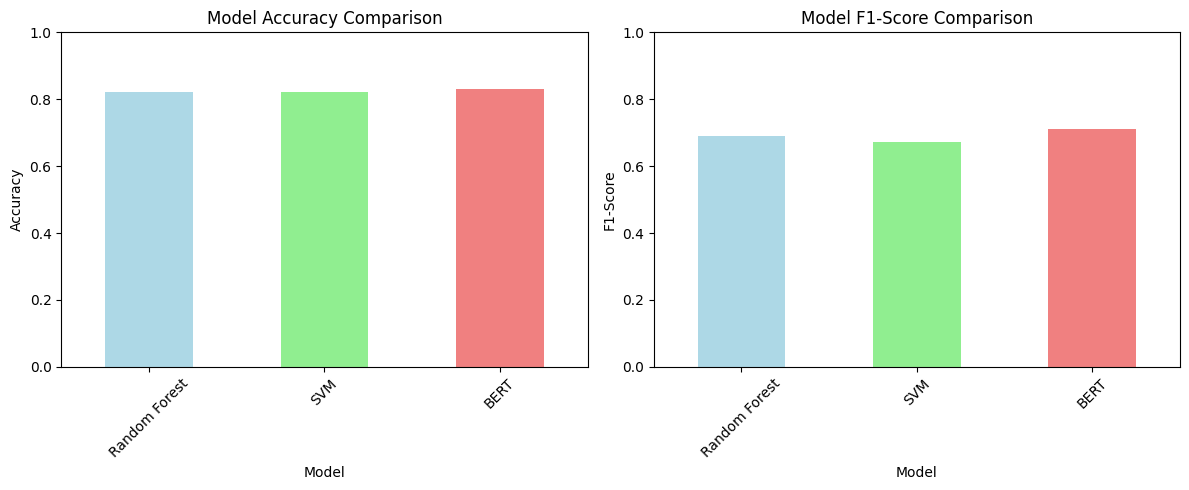


Best performing model: BERT (F1-Score: 0.7123)

SAMPLE PREDICTIONS

Text: You are so stupid and ugly, nobody likes you!
Prediction: Not Cyberbullying
Confidence: 0.9900

Text: Have a great day and enjoy your weekend!
Prediction: Not Cyberbullying
Confidence: 0.9828

Text: I hate all people from that country, they are terrorists
Prediction: Cyberbullying
Confidence: 0.9927


In [ ]:
# Cyberbullying Detection using Traditional ML and Small BERT
# Complete pipeline for text classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# For BERT
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from torch.utils.data import Dataset
import torch.nn.functional as F

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("All required libraries imported successfully!")

# ============================================================================
# 1. DATA LOADING AND EXPLORATION
# ============================================================================

def load_and_explore_data(file_path):
    """Load dataset and perform initial exploration"""
    print("="*50)
    print("LOADING AND EXPLORING DATA")
    print("="*50)

    # Load data
    df = pd.read_csv(file_path)
    print(f"Dataset shape: {df.shape}")
    print(f"\nColumn names: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())

    # Basic info
    print(f"\nDataset Info:")
    print(df.info())

    # Check for missing values
    print(f"\nMissing values:")
    print(df.isnull().sum())

    # Check target variable distribution
    print(f"\nTarget variable (oh_label) distribution:")
    print(df['oh_label'].value_counts())

    # Check annotation distribution
    print(f"\nAnnotation distribution:")
    print(df['Annotation'].value_counts())

    # Plot distributions
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Target distribution
    df['oh_label'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
    axes[0].set_title('Cyberbullying Label Distribution')
    axes[0].set_xlabel('Label (0: Not Cyberbullying, 1: Cyberbullying)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)

    # Annotation distribution
    df['Annotation'].value_counts().plot(kind='bar', ax=axes[1], color=['lightgreen', 'orange', 'red'])
    axes[1].set_title('Annotation Type Distribution')
    axes[1].set_xlabel('Annotation Type')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    return df

# ============================================================================
# 2. TEXT PREPROCESSING
# ============================================================================

class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text):
        """Clean and preprocess text"""
        if pd.isna(text):
            return ""

        # Convert to lowercase
        text = str(text).lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove user mentions and hashtags (keep the text after #)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#', '', text)

        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()

        # Remove numbers
        text = re.sub(r'\d+', '', text)

        return text

    def advanced_clean(self, text):
        """Advanced cleaning with lemmatization and stopword removal"""
        text = self.clean_text(text)

        # Tokenize and remove stopwords
        tokens = [word for word in text.split() if word not in self.stop_words and len(word) > 2]

        # Lemmatize
        tokens = [self.lemmatizer.lemmatize(word) for word in tokens]

        return ' '.join(tokens)

def preprocess_data(df):
    """Preprocess the entire dataset"""
    print("="*50)
    print("PREPROCESSING DATA")
    print("="*50)

    # Handle missing values first
    print("Handling missing values...")
    print(f"Missing values before cleaning:")
    print(df.isnull().sum())

    # Drop rows with missing Text or oh_label
    df = df.dropna(subset=['Text', 'oh_label']).copy()
    print(f"Dataset shape after removing missing values: {df.shape}")

    # Convert oh_label to int (it was float due to NaN values)
    df['oh_label'] = df['oh_label'].astype(int)

    preprocessor = TextPreprocessor()

    # Clean text
    print("Cleaning text data...")
    df['cleaned_text'] = df['Text'].apply(preprocessor.clean_text)
    df['advanced_cleaned_text'] = df['Text'].apply(preprocessor.advanced_clean)

    # Remove empty texts
    df = df[df['advanced_cleaned_text'].str.len() > 0].copy()

    # Reset index after all filtering
    df = df.reset_index(drop=True)

    print(f"Final dataset shape after preprocessing: {df.shape}")
    print(f"Final target distribution:")
    print(df['oh_label'].value_counts())

    print("\nSample cleaned texts:")
    for i in range(min(3, len(df))):
        print(f"\nOriginal: {df.iloc[i]['Text']}")
        print(f"Cleaned: {df.iloc[i]['advanced_cleaned_text']}")

    return df

# ============================================================================
# 3. TRADITIONAL ML MODELS
# ============================================================================

class TraditionalMLModels:
    def __init__(self):
        self.vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
        self.models = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(kernel='rbf', random_state=42)
        }
        self.trained_models = {}

    def train_models(self, X_train, y_train, X_test, y_test):
        """Train traditional ML models"""
        print("="*50)
        print("TRAINING TRADITIONAL ML MODELS")
        print("="*50)

        # Vectorize text
        print("Vectorizing text using TF-IDF...")
        X_train_vec = self.vectorizer.fit_transform(X_train)
        X_test_vec = self.vectorizer.transform(X_test)

        print(f"Feature vector shape: {X_train_vec.shape}")

        results = {}

        for name, model in self.models.items():
            print(f"\nTraining {name}...")

            # Train model
            model.fit(X_train_vec, y_train)
            self.trained_models[name] = model

            # Predictions
            y_pred = model.predict(X_test_vec)

            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            results[name] = {
                'accuracy': accuracy,
                'f1_score': f1,
                'predictions': y_pred
            }

            print(f"{name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

            # Classification report
            print(f"\nClassification Report for {name}:")
            print(classification_report(y_test, y_pred))

            # Confusion Matrix
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(6, 4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Not Cyberbullying', 'Cyberbullying'],
                       yticklabels=['Not Cyberbullying', 'Cyberbullying'])
            plt.title(f'Confusion Matrix - {name}')
            plt.ylabel('Actual')
            plt.xlabel('Predicted')
            plt.show()

        return results

    def hyperparameter_tuning(self, X_train, y_train):
        """Perform hyperparameter tuning"""
        print("="*50)
        print("HYPERPARAMETER TUNING")
        print("="*50)

        X_train_vec = self.vectorizer.fit_transform(X_train)

        # Random Forest tuning
        print("Tuning Random Forest...")
        rf_params = {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10]
        }

        rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                              rf_params, cv=3, scoring='f1', n_jobs=-1)
        rf_grid.fit(X_train_vec, y_train)

        print(f"Best RF parameters: {rf_grid.best_params_}")
        print(f"Best RF score: {rf_grid.best_score_:.4f}")

        self.models['Random Forest'] = rf_grid.best_estimator_

        # SVM tuning
        print("\nTuning SVM...")
        svm_params = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf', 'linear']
        }

        svm_grid = GridSearchCV(SVC(random_state=42),
                               svm_params, cv=3, scoring='f1', n_jobs=-1)
        svm_grid.fit(X_train_vec, y_train)

        print(f"Best SVM parameters: {svm_grid.best_params_}")
        print(f"Best SVM score: {svm_grid.best_score_:.4f}")

        self.models['SVM'] = svm_grid.best_estimator_

# ============================================================================
# 4. BERT MODEL
# ============================================================================

class CyberbullyingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class BERTClassifier:
    def __init__(self, model_name='prajjwal1/bert-small'):
        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2
        )

        # Move model to GPU if available
        self.model.to(self.device)

        if torch.cuda.is_available():
            print(f"GPU: {torch.cuda.get_device_name(0)}")
            print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
        else:
            print("No GPU available, training will be slow on CPU")

    def prepare_data(self, X_train, y_train, X_val, y_val):
        """Prepare data for BERT training"""
        self.train_dataset = CyberbullyingDataset(
            X_train.values, y_train.values, self.tokenizer
        )
        self.val_dataset = CyberbullyingDataset(
            X_val.values, y_val.values, self.tokenizer
        )

    def train_model(self, output_dir='./bert_cyberbullying'):
        """Train BERT model with manual training loop"""
        print("="*50)
        print("TRAINING BERT MODEL (Manual Loop)")
        print("="*50)

        # Set up device and batch sizes
        if torch.cuda.is_available():
            gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
            train_batch_size = 16 if gpu_memory_gb >= 8 else 8
            eval_batch_size = 32 if gpu_memory_gb >= 8 else 16
            print(f"GPU detected ({gpu_memory_gb:.1f}GB). Using batch sizes: train={train_batch_size}, eval={eval_batch_size}")
        else:
            train_batch_size = 4
            eval_batch_size = 8
            print("CPU training detected.")

        # Create data loaders
        from torch.utils.data import DataLoader

        train_dataloader = DataLoader(
            self.train_dataset,
            batch_size=train_batch_size,
            shuffle=True,
            collate_fn=DataCollatorWithPadding(self.tokenizer)
        )
        eval_dataloader = DataLoader(
            self.val_dataset,
            batch_size=eval_batch_size,
            shuffle=False,
            collate_fn=DataCollatorWithPadding(self.tokenizer)
        )

        # Set up optimizer
        from torch.optim import AdamW
        optimizer = AdamW(self.model.parameters(), lr=2e-5, weight_decay=0.01)

        # Training parameters
        num_epochs = 10  # Reduced for faster training
        total_steps = len(train_dataloader) * num_epochs

        print(f"Training batches per epoch: {len(train_dataloader)}")
        print(f"Validation batches: {len(eval_dataloader)}")
        print(f"Total training steps: {total_steps}")
        print("="*50)

        # Clear GPU cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        try:
            import time
            start_time = time.time()

            self.model.train()

            for epoch in range(num_epochs):
                print(f"\n📚 Epoch {epoch + 1}/{num_epochs}")
                print("-" * 30)

                total_loss = 0
                num_batches = len(train_dataloader)

                for batch_idx, batch in enumerate(train_dataloader):
                    # Move batch to device
                    batch = {k: v.to(self.device) for k, v in batch.items()}

                    # Forward pass
                    outputs = self.model(**batch)
                    loss = outputs.loss

                    # Backward pass
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    total_loss += loss.item()

                    # Progress reporting
                    if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == num_batches:
                        avg_loss = total_loss / (batch_idx + 1)
                        progress = ((batch_idx + 1) / num_batches) * 100
                        print(f"  Batch {batch_idx + 1}/{num_batches} ({progress:.1f}%) - Avg Loss: {avg_loss:.4f}")

                # Validation
                print(f"\n🔍 Validating epoch {epoch + 1}...")
                self.model.eval()
                val_loss = 0
                val_batches = 0

                with torch.no_grad():
                    for val_batch in eval_dataloader:
                        val_batch = {k: v.to(self.device) for k, v in val_batch.items()}
                        val_outputs = self.model(**val_batch)
                        val_loss += val_outputs.loss.item()
                        val_batches += 1

                avg_val_loss = val_loss / val_batches
                avg_train_loss = total_loss / len(train_dataloader)

                print(f"  ✅ Epoch {epoch + 1} Complete!")
                print(f"  📊 Train Loss: {avg_train_loss:.4f}")
                print(f"  📊 Val Loss: {avg_val_loss:.4f}")

                self.model.train()

            end_time = time.time()
            training_time = (end_time - start_time) / 60

            print(f"\n🎉 Training completed successfully!")
            print(f"⏱️ Total time: {training_time:.2f} minutes")

            # Save model
            import os
            os.makedirs(output_dir, exist_ok=True)
            self.model.save_pretrained(output_dir)
            self.tokenizer.save_pretrained(output_dir)

            print(f"💾 Model saved to: {output_dir}")

            return None  # Return None since we're not using Trainer

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("❌ GPU out of memory! Try restarting and reducing batch size.")
            raise e
        except KeyboardInterrupt:
            print("\n⚠️ Training interrupted by user")
            raise
        except Exception as e:
            print(f"❌ Training failed: {str(e)}")
            raise e

    def evaluate_model(self, X_test, y_test):
        """Evaluate BERT model"""
        print("="*50)
        print("EVALUATING BERT MODEL")
        print("="*50)

        predictions = []

        # Set model to evaluation mode
        self.model.eval()

        print(f"Evaluating on {len(X_test)} samples...")

        # Process in batches for efficiency
        batch_size = 32 if torch.cuda.is_available() else 8

        with torch.no_grad():
            for i in range(0, len(X_test), batch_size):
                batch_texts = X_test.iloc[i:i+batch_size].values
                batch_predictions = []

                for text in batch_texts:
                    # Tokenize
                    inputs = self.tokenizer(
                        str(text),
                        truncation=True,
                        padding='max_length',
                        max_length=128,
                        return_tensors='pt'
                    )

                    # Move to device
                    inputs = {k: v.to(self.device) for k, v in inputs.items()}

                    # Predict
                    outputs = self.model(**inputs)
                    logits = outputs.logits
                    predicted = torch.argmax(F.softmax(logits, dim=-1), dim=-1)
                    batch_predictions.append(predicted.cpu().item())

                predictions.extend(batch_predictions)

                # Progress indicator
                if i % (batch_size * 10) == 0:
                    print(f"Processed {min(i + batch_size, len(X_test))}/{len(X_test)} samples")

        # Calculate metrics
        accuracy = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        print(f"BERT Model - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

        # Classification report
        print("\nBERT Classification Report:")
        print(classification_report(y_test, predictions))

        # Confusion Matrix
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Not Cyberbullying', 'Cyberbullying'],
                   yticklabels=['Not Cyberbullying', 'Cyberbullying'])
        plt.title('Confusion Matrix - BERT Model')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

        return {
            'accuracy': accuracy,
            'f1_score': f1,
            'predictions': predictions
        }

# ============================================================================
# 5. MAIN EXECUTION PIPELINE
# ============================================================================

def main_pipeline(file_path, skip_bert=False):
    """Main execution pipeline"""
    print("CYBERBULLYING DETECTION PIPELINE STARTED")
    print("="*60)

    try:
        # 1. Load and explore data
        df = load_and_explore_data(file_path)

        # 2. Preprocess data
        df = preprocess_data(df)

        # Check if we have enough data after preprocessing
        if len(df) < 100:
            raise ValueError("Not enough data after preprocessing. Need at least 100 samples.")

        # Check target distribution
        target_dist = df['oh_label'].value_counts()
        if len(target_dist) < 2:
            raise ValueError("Target variable must have both classes (0 and 1)")

        print(f"Final data distribution: Class 0: {target_dist[0]}, Class 1: {target_dist[1]}")

        # 3. Prepare data for modeling
        X = df['advanced_cleaned_text']
        y = df['oh_label']

        # Verify no NaN values remain
        if X.isnull().any() or y.isnull().any():
            raise ValueError("Still have missing values after preprocessing!")

        # Split data
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
        )

        print(f"\nData splits:")
        print(f"Training set: {len(X_train)} (Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)})")
        print(f"Validation set: {len(X_val)} (Class 0: {sum(y_val==0)}, Class 1: {sum(y_val==1)})")
        print(f"Test set: {len(X_test)} (Class 0: {sum(y_test==0)}, Class 1: {sum(y_test==1)})")

        # 4. Train Traditional ML Models
        print("\nStarting traditional ML model training...")
        ml_models = TraditionalMLModels()

        # Optional: Hyperparameter tuning (uncomment if needed)
        # ml_models.hyperparameter_tuning(X_train, y_train)

        traditional_results = ml_models.train_models(X_train, y_train, X_test, y_test)

        all_results = traditional_results.copy()

        # 5. Train BERT Model (optional)
        if not skip_bert:
            print("\nStarting BERT model training...")
            try:
                bert_classifier = BERTClassifier()
                bert_classifier.prepare_data(X_train, y_train, X_val, y_val)
                bert_trainer = bert_classifier.train_model()
                bert_results = bert_classifier.evaluate_model(X_test, y_test)
                all_results['BERT'] = bert_results
            except Exception as e:
                print(f"BERT training failed: {str(e)}")
                print("Continuing with traditional ML results only...")
        else:
            print("\nSkipping BERT training (skip_bert=True)")

        # 6. Compare Results
        print("="*60)
        print("FINAL RESULTS COMPARISON")
        print("="*60)

        # Create comparison DataFrame
        comparison_df = pd.DataFrame({
            'Model': list(all_results.keys()),
            'Accuracy': [results['accuracy'] for results in all_results.values()],
            'F1-Score': [results['f1_score'] for results in all_results.values()]
        })

        print(comparison_df)

        # Plot comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Accuracy comparison
        comparison_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0],
                          color=['lightblue', 'lightgreen', 'lightcoral'], legend=False)
        axes[0].set_title('Model Accuracy Comparison')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_ylim(0, 1)
        axes[0].tick_params(axis='x', rotation=45)

        # F1-Score comparison
        comparison_df.plot(x='Model', y='F1-Score', kind='bar', ax=axes[1],
                          color=['lightblue', 'lightgreen', 'lightcoral'], legend=False)
        axes[1].set_title('Model F1-Score Comparison')
        axes[1].set_ylabel('F1-Score')
        axes[1].set_ylim(0, 1)
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

        # Find best model
        best_model_idx = comparison_df['F1-Score'].idxmax()
        best_model = comparison_df.iloc[best_model_idx]['Model']
        best_f1 = comparison_df.iloc[best_model_idx]['F1-Score']

        print(f"\nBest performing model: {best_model} (F1-Score: {best_f1:.4f})")

        return all_results, comparison_df

    except Exception as e:
        print(f"Error in main pipeline: {str(e)}")
        import traceback
        traceback.print_exc()
        raise

# ============================================================================
# 6. PREDICTION FUNCTION
# ============================================================================

def predict_new_text(text, model_type='bert'):
    """Function to predict cyberbullying for new text"""
    preprocessor = TextPreprocessor()

    if model_type == 'bert':
        # Load trained BERT model
        tokenizer = AutoTokenizer.from_pretrained('./bert_cyberbullying')
        model = AutoModelForSequenceClassification.from_pretrained('./bert_cyberbullying')

        # Preprocess text
        cleaned_text = preprocessor.clean_text(text)

        # Tokenize and predict
        inputs = tokenizer(
            cleaned_text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probabilities = F.softmax(logits, dim=-1)
            predicted = torch.argmax(probabilities, dim=-1)

        confidence = probabilities[0][predicted].item()
        prediction = predicted.item()

    else:
        # Use traditional ML models (would need to save/load vectorizer and model)
        print("Traditional ML prediction requires saved models")
        return None

    result = {
        'text': text,
        'prediction': 'Cyberbullying' if prediction == 1 else 'Not Cyberbullying',
        'confidence': confidence
    }

    return result

# ============================================================================
# 7. USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Replace with your actual file path
    FILE_PATH = "/kaggle/input/cyberbullying-dataset/twitter_parsed_dataset.csv"

    try:
        # Option 1: Run only traditional ML models (fast)
        print("Option 1: Traditional ML only (recommended to start)")
        print("Option 2: Include BERT training (requires GPU for reasonable speed)")

        # Set to True to skip BERT and just run traditional ML models
        SKIP_BERT = False  # Change to False if you want to include BERT

        if SKIP_BERT:
            print("\n>>> Running TRADITIONAL ML MODELS ONLY <<<")
        else:
            print("\n>>> Running ALL MODELS (including BERT) <<<")

        # Run the complete pipeline
        results, comparison_df = main_pipeline(FILE_PATH, skip_bert=SKIP_BERT)

        # Example predictions on new text (only if BERT was trained)
        sample_texts = [
            "You are so stupid and ugly, nobody likes you!",
            "Have a great day and enjoy your weekend!",
            "I hate all people from that country, they are terrorists"
        ]

        if not SKIP_BERT:
            print("\n" + "="*60)
            print("SAMPLE PREDICTIONS")
            print("="*60)

            for text in sample_texts:
                try:
                    prediction = predict_new_text(text, model_type='bert')
                    if prediction:
                        print(f"\nText: {text}")
                        print(f"Prediction: {prediction['prediction']}")
                        print(f"Confidence: {prediction['confidence']:.4f}")
                except Exception as e:
                    print(f"Error predicting for text: {text}")
                    print(f"Error: {str(e)}")
        else:
            print("\n" + "="*60)
            print("SAMPLE TRADITIONAL ML PREDICTIONS")
            print("="*60)
            print("Note: Set SKIP_BERT=False to enable BERT predictions")

    except FileNotFoundError:
        print(f"Error: Could not find the file '{FILE_PATH}'")
        print("Please make sure the file exists and the path is correct.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        print("Please check your data format and try again.")
